# Retail Store Daily Sales Forecaster & Stock-Out Alert System

**Goal:** forecast daily sales for the next 7 / 14 / 30 days for a store and product category, show the uncertainty (confidence interval), and raise an alert if the forecast demand is more than the stock we have.

**Steps:** Load data → Clean → Explore → Pick store & category → Build time series → Prophet & Holt-Winters → Compare models → 7/14/30-day forecast → Stock alert

**Data:** Favorita grocery sales (Ecuador), 2013-01-01 to 2017-08-15 – `train.csv`, `stores.csv`, `holidays_events.csv`, `transactions.csv` (kept in a folder called `Data`).

## 1. Import libraries

In [52]:
import numpy as np
import pandas as pd

## 2. Load the data

In [53]:
df = pd.read_csv("Data/train.csv", parse_dates=["date"])
stores = pd.read_csv("Data/stores.csv")
holidays_raw = pd.read_csv("Data/holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv("Data/transactions.csv", parse_dates=["date"])

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [54]:
print(df.shape)

(3000888, 6)


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


## 3. Data cleaning

In [56]:
# Give the columns clearer names
df = df.rename(columns={"family": "Category", "onpromotion": "Promotion"})

# Sort by store, category and date
df = df.sort_values(["store_nbr", "Category", "date"]).reset_index(drop=True)
df.head()

,id,date,store_nbr,Category,sales,Promotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
2,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
3,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
4,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


In [57]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated(["store_nbr", "Category", "date"]).sum())
print("Negative sales:", (df["sales"] < 0).sum())

Missing values:
id           0
date         0
store_nbr    0
Category     0
sales        0
Promotion    0
dtype: int64

Duplicate rows: 0
Negative sales: 0


In [58]:
print("Number of stores:", df["store_nbr"].nunique())
print("Number of categories:", df["Category"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Number of stores: 54
Number of categories: 33
Date range: 2013-01-01 to 2017-08-15


In [59]:
# missing date
all_days = pd.date_range(df["date"].min(), df["date"].max())
missing_days = all_days.difference(df["date"].unique())
print(missing_days)

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Top stores and top categories

In [60]:
top_stores = df.groupby("store_nbr")["sales"].sum().sort_values(ascending=False).head(10)
top_categories = df.groupby("Category")["sales"].sum().sort_values(ascending=False).head(10)

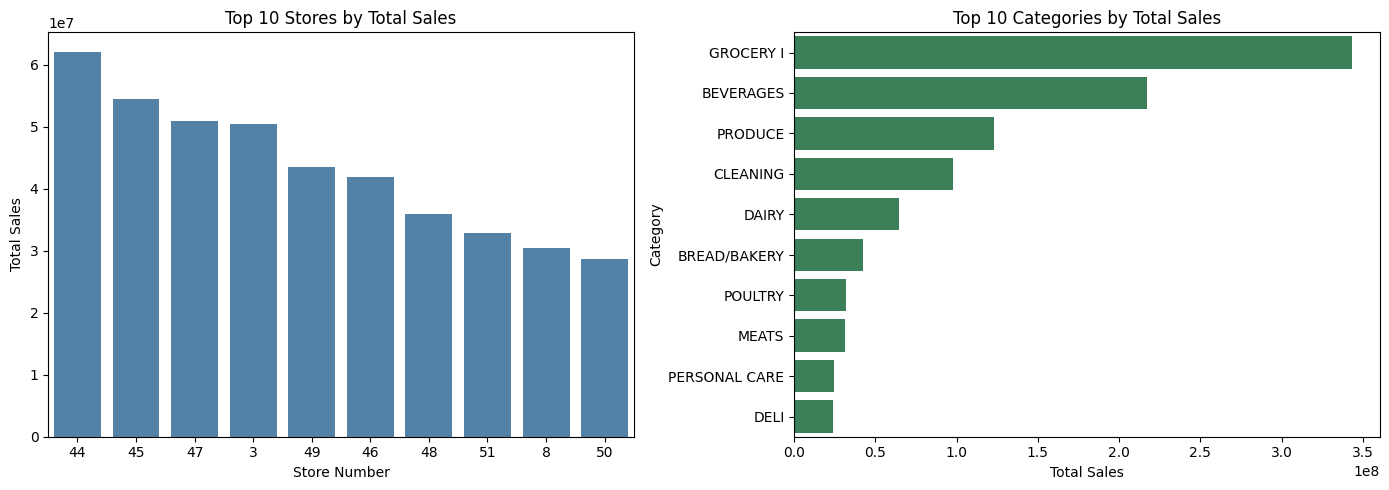

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=top_stores.index.astype(str), y=top_stores.values, color="steelblue")
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")

plt.subplot(1, 2, 2)
sns.barplot(x=top_categories.values, y=top_categories.index, color="seagreen")
plt.title("Top 10 Categories by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [62]:
top5_stores = list(top_stores.head(5).index)
top5_categories = list(top_categories.head(5).index)
print("Top 5 stores:", top5_stores)
print("Top 5 categories:", top5_categories)

Top 5 stores: [44, 45, 47, 3, 49]
Top 5 categories: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']


### 4.2 Total sales over time

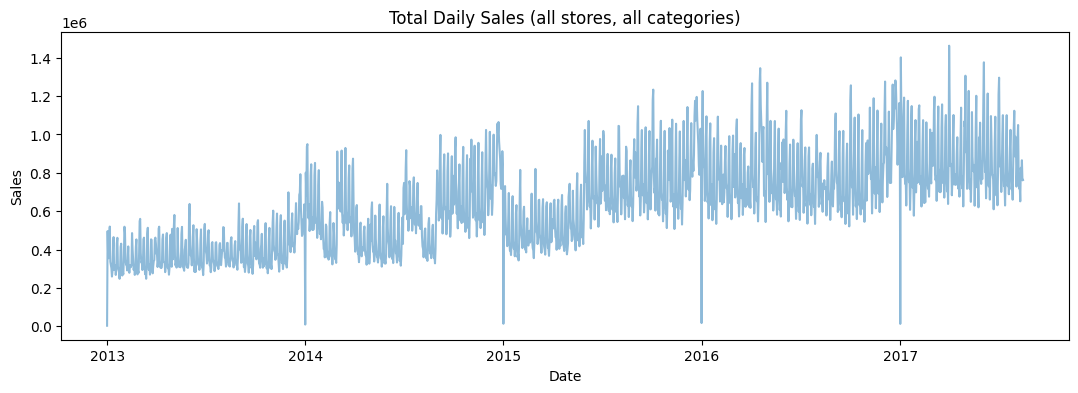

In [63]:
daily_total = df.groupby("date")["sales"].sum()

plt.figure(figsize=(13, 4))
plt.plot(daily_total.index, daily_total.values, alpha=0.5)
plt.title("Total Daily Sales (all stores, all categories)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### 4.3 Average sales by month

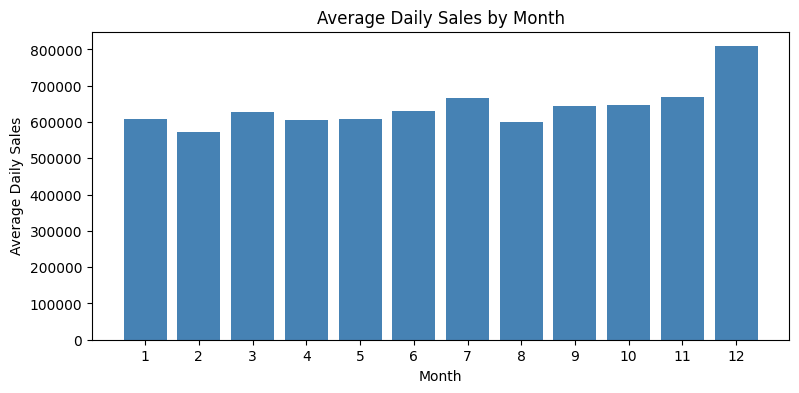

In [64]:
month_sales = daily_total.groupby(daily_total.index.month).mean()

plt.figure(figsize=(9, 4))
plt.bar(month_sales.index, month_sales.values, color="steelblue")
plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(range(1, 13))
plt.show()

### 4.4 Average sales by day of the week

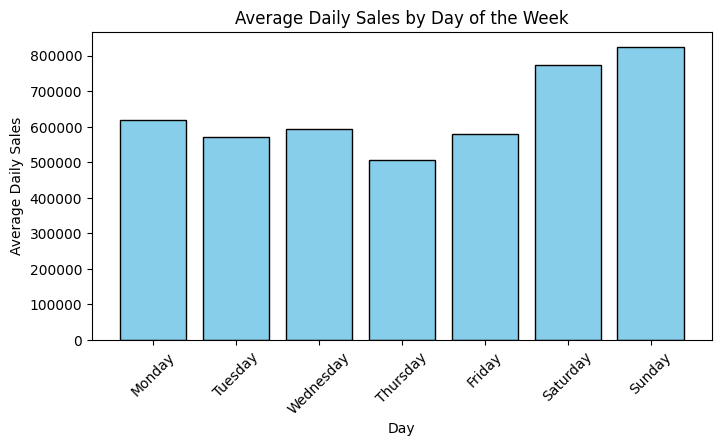

In [65]:
day_sales = daily_total.groupby(daily_total.index.day_name()).mean()
day_sales = day_sales.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(8, 4))
plt.bar(day_sales.index, day_sales.values, color="skyblue", edgecolor="black")
plt.title("Average Daily Sales by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.show()

Sales have a clear **weekly pattern**

### 4.5 Sales by store type

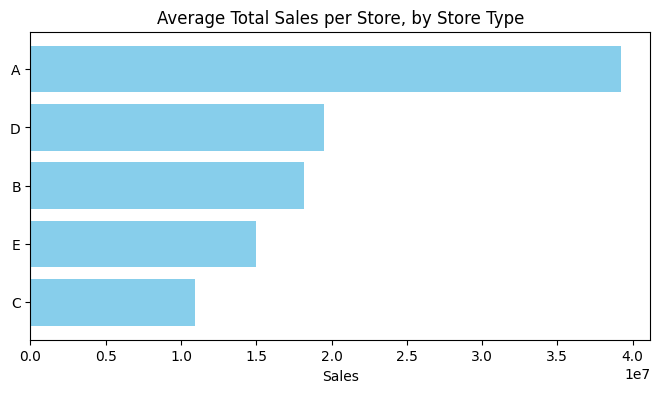

In [66]:
store_sales = df.groupby("store_nbr")["sales"].sum().reset_index()
store_sales = store_sales.merge(stores, on="store_nbr")

type_sales = store_sales.groupby("type")["sales"].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(type_sales.index, type_sales.values, color="skyblue")
plt.title("Average Total Sales per Store, by Store Type")
plt.xlabel("Sales")
plt.show()

Type A: Type A stores generate highest average total sales

Types D, B, and E: Type D comes in second followed closely by Type B and Type E.

Type C: Type C stores have the lowest average total sales among all classifications.

## 5. Select a store and category, create the time series

In [67]:
store = 44
category = "GROCERY I"

subset = df[(df["store_nbr"] == store) & (df["Category"] == category)]
subset = subset[["date", "sales", "Promotion"]]
subset = subset.rename(columns={"date": "ds", "sales": "y", "Promotion": "promo"})

subset = subset.set_index("ds").asfreq("D").reset_index()
subset["promo"] = subset["promo"].fillna(0)

subset.head()

,ds,y,promo
0,2013-01-01,0.0,0.0
1,2013-01-02,10686.0,0.0
2,2013-01-03,7342.0,0.0
3,2013-01-04,7250.0,0.0
4,2013-01-05,10699.0,0.0


In [68]:
print("Rows:", len(subset))
print("From", subset["ds"].min().date(), "to", subset["ds"].max().date())
print("Missing days:", subset["y"].isnull().sum())

Rows: 1688
From 2013-01-01 to 2017-08-15
Missing days: 4


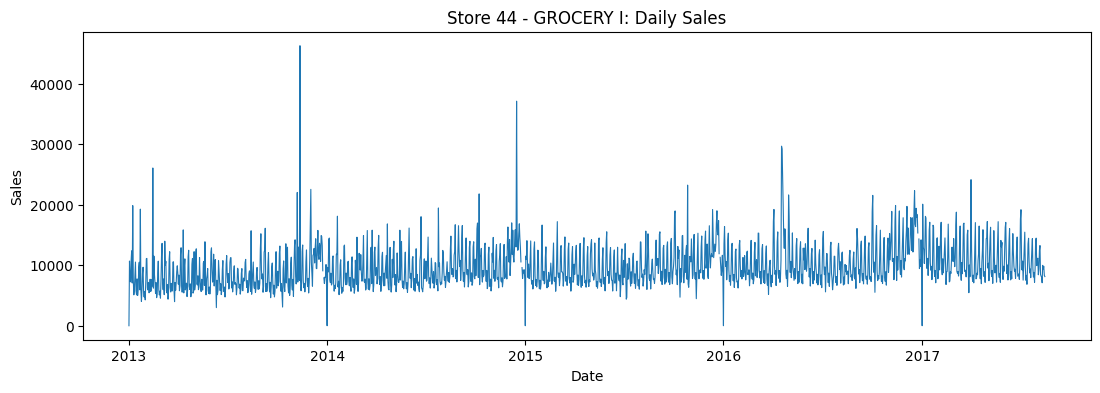

In [69]:
plt.figure(figsize=(13, 4))
plt.plot(subset["ds"], subset["y"], linewidth=0.8)
plt.title("Store 44 - GROCERY I: Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

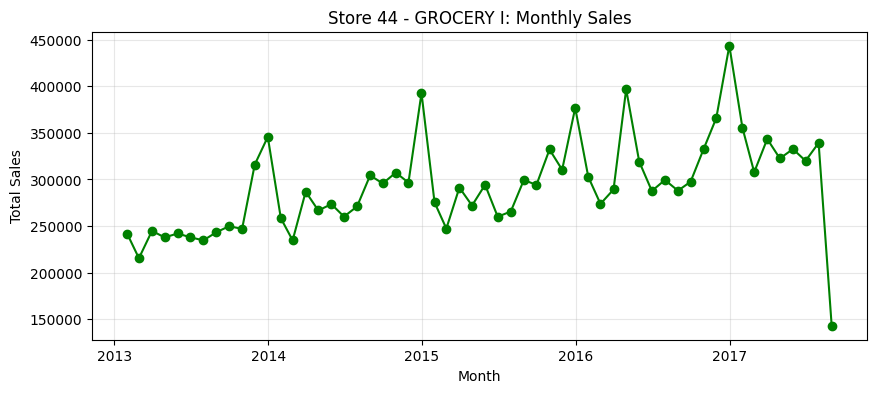

In [70]:
monthly = subset.set_index("ds")["y"].resample("ME").sum()

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly.values, marker="o", color="green")
plt.title("Store 44 - GROCERY I: Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True, alpha=0.3)
plt.show()

### 5.1 Does promotion affect sales?

                     mean   median
promo_group                       
0             8479.119782   7375.0
1-20          9817.054869   8675.0
21-40        10340.504065   8962.0
41-60        10147.113924   9057.5
61-80        10753.708333   9842.0
81-100       10832.915888   9563.0
100+         12386.255556  11811.0


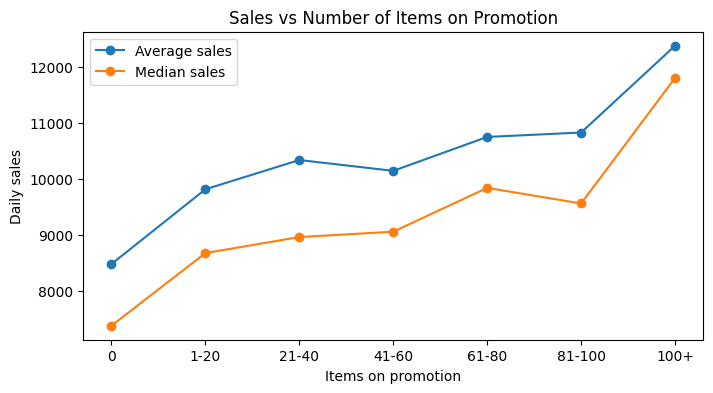

In [71]:
subset["promo_group"] = pd.cut(subset["promo"],
                               bins=[-1, 0, 20, 40, 60, 80, 100, 10000],
                               labels=["0", "1-20", "21-40", "41-60", "61-80", "81-100", "100+"])

promo_summary = subset.groupby("promo_group", observed=True)["y"].agg(["mean", "median"])
print(promo_summary)

plt.figure(figsize=(8, 4))
plt.plot(promo_summary.index, promo_summary["mean"], marker="o", label="Average sales")
plt.plot(promo_summary.index, promo_summary["median"], marker="o", label="Median sales")
plt.title("Sales vs Number of Items on Promotion")
plt.xlabel("Items on promotion")
plt.ylabel("Daily sales")
plt.legend()
plt.show()

**More items on promotion** gives increasing in **Average sales** and **Median sales**

### 5.2 Do holidays affect sales?

In [72]:
holidays = holidays_raw[(holidays_raw["locale"] == "National") & (holidays_raw["transferred"] == False)]
holidays = holidays[["description", "date"]].rename(columns={"description": "holiday", "date": "ds"})
holidays = holidays.drop_duplicates().reset_index(drop=True)
print("Number of holiday dates:", len(holidays))

relative_sales = subset.set_index("ds")["y"] / subset.set_index("ds")["y"].rolling(28, center=True, min_periods=7).mean()
is_holiday = relative_sales.index.isin(holidays["ds"])

print("Holidays   :", round(relative_sales[is_holiday].mean(), 3))
print("Normal days:", round(relative_sales[~is_holiday].mean(), 3))

Number of holiday dates: 166
Holidays   : 1.057
Normal days: 0.994


Holiday sales are about 6% above normal, so holidays are also given to Prophet.

## 6. Forecasting – train and test split

In [73]:
test_days = 30

train = subset.iloc[:-test_days]
test = subset.iloc[-test_days:]

print("Train:", train["ds"].min().date(), "to", train["ds"].max().date())
print("Test :", test["ds"].min().date(), "to", test["ds"].max().date())

Train: 2013-01-01 to 2017-07-16
Test : 2017-07-17 to 2017-08-15


### 6.1 Model 1 – Prophet

In [ ]:
from prophet import Prophet

prophet_model = Prophet(weekly_seasonality=True,
                        yearly_seasonality=True,
                        daily_seasonality=False,
                        holidays=holidays,
                        interval_width=0.80)          # 80% confidence interval
prophet_model.add_regressor("promo")
prophet_model.fit(train[["ds", "y", "promo"]].dropna())

13:13:58 - cmdstanpy - INFO - Chain [1] start processing
13:13:59 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future = test[["ds", "promo"]]
prophet_test = prophet_model.predict(future)

prophet_test = prophet_test[["ds", "yhat", "yhat_lower", "yhat_upper"]]
prophet_test.head()

,ds,yhat,yhat_lower,yhat_upper
0,2017-07-17,10001.167907,7158.468563,12834.358382
1,2017-07-18,9614.782543,6715.954405,12483.082812
2,2017-07-19,10393.851602,7487.345744,13215.973229
3,2017-07-20,8739.271438,5882.022918,11534.541538
4,2017-07-21,9961.977458,7022.730281,12822.707698


### 6.2 Model 2 – Holt-Winters (Exponential Smoothing)

In [76]:
y_train = train.set_index("ds")["y"].asfreq("D").interpolate()     # fill the 25-Dec gaps

In [ ]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel   # Holt-Winters

hw_model = ETSModel(y_train,
                    error="add",
                    trend="add",
                    damped_trend=True,
                    seasonal="add",
                    seasonal_periods=7)
hw_fit = hw_model.fit(disp=False)

In [78]:
hw_pred = hw_fit.get_prediction(start=len(y_train), end=len(y_train) + test_days - 1)
hw_test = hw_pred.summary_frame(alpha=0.20)             # alpha 0.20 = 80% interval

hw_test = hw_test.rename(columns={"mean": "yhat", "pi_lower": "yhat_lower", "pi_upper": "yhat_upper"})
hw_test["ds"] = test["ds"].values
hw_test = hw_test[["ds", "yhat", "yhat_lower", "yhat_upper"]]
hw_test.head()

,ds,yhat,yhat_lower,yhat_upper
2017-07-17,2017-07-17,9084.371873,5598.850876,12569.892871
2017-07-18,2017-07-18,7853.408207,4342.382917,11364.433497
2017-07-19,2017-07-19,8984.256029,5447.906067,12520.605992
2017-07-20,2017-07-20,7240.577759,3679.079234,10802.076283
2017-07-21,2017-07-21,10122.054210,6535.579826,13708.528595


### 6.3 Compare predictions with the real sales

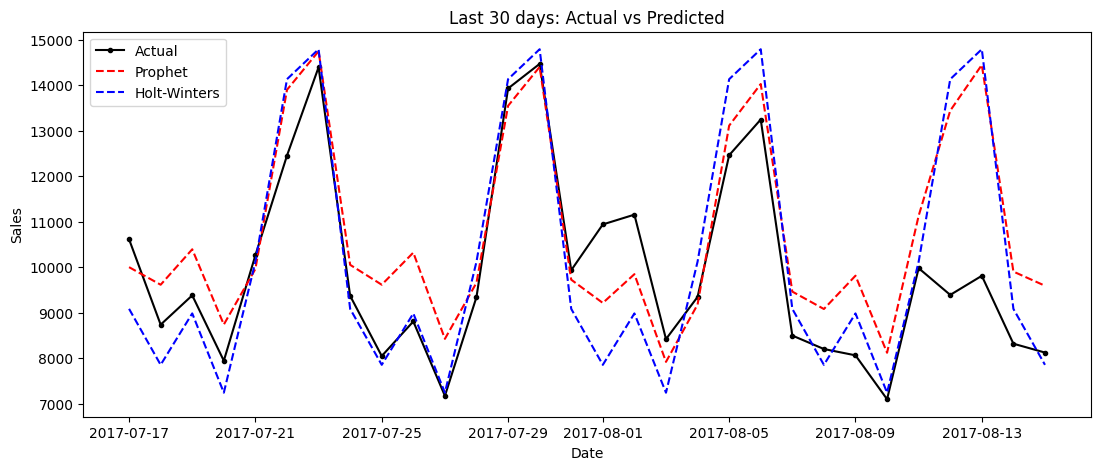

In [79]:
actual = test["y"].values

plt.figure(figsize=(13, 5))
plt.plot(test["ds"], actual, color="black", marker="o", markersize=3, label="Actual")
plt.plot(prophet_test["ds"], prophet_test["yhat"], "--", color="red", label="Prophet")
plt.plot(hw_test["ds"], hw_test["yhat"], "--", color="blue", label="Holt-Winters")
plt.title("Last 30 days: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

### 6.4 Error metrics
* **MAE** – average size of the mistake (in units)
* **RMSE** – like MAE but punishes big mistakes more
* **WAPE %** – total mistake ÷ total sales (a simple "% off")
* **Coverage %** – how many real values fell inside the 80% interval (should be near 80%)

In [80]:
# Prophet
error = actual - prophet_test["yhat"].values
prophet_mae = np.mean(np.abs(error))
prophet_rmse = np.sqrt(np.mean(error ** 2))
prophet_wape = np.sum(np.abs(error)) / np.sum(actual) * 100
prophet_cov = np.mean((actual >= prophet_test["yhat_lower"].values) & (actual <= prophet_test["yhat_upper"].values)) * 100

# Holt-Winters
error = actual - hw_test["yhat"].values
hw_mae = np.mean(np.abs(error))
hw_rmse = np.sqrt(np.mean(error ** 2))
hw_wape = np.sum(np.abs(error)) / np.sum(actual) * 100
hw_cov = np.mean((actual >= hw_test["yhat_lower"].values) & (actual <= hw_test["yhat_upper"].values)) * 100

results = pd.DataFrame({"Model": ["Prophet", "Holt-Winters"],
                        "MAE": [prophet_mae, hw_mae],
                        "RMSE": [prophet_rmse, hw_rmse],
                        "WAPE %": [prophet_wape, hw_wape],
                        "Coverage %": [prophet_cov, hw_cov]})
results.round(2)

,Model,MAE,RMSE,WAPE %,Coverage %
0,Prophet,1134.68,1505.03,11.43,93.33
1,Holt-Winters,1064.90,1624.50,10.72,93.33


### 6.5 Testing on more series (top 5 stores × top 5 categories = 25 series)

One series can be lucky, so we repeat the same train / test steps for 25 series and compare the average error.

In [81]:
all_results = []

for s in top5_stores:
    for c in top5_categories:

        d = df[(df["store_nbr"] == s) & (df["Category"] == c)]
        d = d[["date", "sales", "Promotion"]].rename(columns={"date": "ds", "sales": "y", "Promotion": "promo"})
        d = d.set_index("ds").asfreq("D").reset_index()
        d["promo"] = d["promo"].fillna(0)
        d = d[d["ds"] >= d.loc[d["y"] > 0, "ds"].min()]       # start at the first real sale

        d_train = d.iloc[:-30]
        d_test = d.iloc[-30:].dropna(subset=["y"])
        d_actual = d_test["y"].values

        # Prophet
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True, holidays=holidays, interval_width=0.80)
        m.add_regressor("promo")
        m.fit(d_train[["ds", "y", "promo"]].dropna())
        p = m.predict(d_test[["ds", "promo"]])

        # Holt-Winters
        y_tr = d_train.set_index("ds")["y"].asfreq("D").interpolate()
        h = ETSModel(y_tr, error="add", trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit(disp=False)
        hp = h.get_prediction(start=len(y_tr), end=len(y_tr) + len(d_test) - 1).summary_frame(alpha=0.20)

        hw_values = hp["mean"].values[:len(d_test)]

        e1 = d_actual - p["yhat"].values
        e2 = d_actual - hw_values
        all_results.append([s, c, "Prophet", np.mean(np.abs(e1)), np.sqrt(np.mean(e1**2)), np.sum(np.abs(e1)) / np.sum(d_actual) * 100])
        all_results.append([s, c, "Holt-Winters", np.mean(np.abs(e2)), np.sqrt(np.mean(e2**2)), np.sum(np.abs(e2)) / np.sum(d_actual) * 100])

all_results = pd.DataFrame(all_results, columns=["Store", "Category", "Model", "MAE", "RMSE", "WAPE %"])
all_results.head()

13:14:00 - cmdstanpy - INFO - Chain [1] start processing
13:14:00 - cmdstanpy - INFO - Chain [1] done processing
13:14:01 - cmdstanpy - INFO - Chain [1] start processing
13:14:01 - cmdstanpy - INFO - Chain [1] done processing
13:14:01 - cmdstanpy - INFO - Chain [1] start processing
13:14:01 - cmdstanpy - INFO - Chain [1] done processing
13:14:02 - cmdstanpy - INFO - Chain [1] start processing
13:14:02 - cmdstanpy - INFO - Chain [1] done processing
13:14:02 - cmdstanpy - INFO - Chain [1] start processing
13:14:03 - cmdstanpy - INFO - Chain [1] done processing
13:14:03 - cmdstanpy - INFO - Chain [1] start processing
13:14:03 - cmdstanpy - INFO - Chain [1] done processing
13:14:04 - cmdstanpy - INFO - Chain [1] start processing
13:14:04 - cmdstanpy - INFO - Chain [1] done processing
13:14:04 - cmdstanpy - INFO - Chain [1] start processing
13:14:04 - cmdstanpy - INFO - Chain [1] done processing
13:14:05 - cmdstanpy - INFO - Chain [1] start processing
13:14:05 - cmdstanpy - INFO - Chain [1]

,Store,Category,Model,MAE,RMSE,WAPE %
0,44,GROCERY I,Prophet,1123.370942,1491.032951,11.312178
1,44,GROCERY I,Holt-Winters,1051.456173,1607.726256,10.588007
2,44,BEVERAGES,Prophet,1738.086234,1982.157364,17.502681
3,44,BEVERAGES,Holt-Winters,1812.773461,2424.326420,18.254788
4,44,PRODUCE,Prophet,1811.028659,2201.205133,19.127394


In [82]:
average_error = all_results.groupby("Model")[["MAE", "RMSE", "WAPE %"]].mean()
average_error.round(2)

,MAE,RMSE,WAPE %
Model,,,
Holt-Winters,676.77,928.21,11.42
Prophet,856.96,1051.12,13.74


In [83]:
# Which model is better for each of the 25 series?
best = all_results.loc[all_results.groupby(["Store", "Category"])["WAPE %"].idxmin()]
print(best["Model"].value_counts())

Model
Holt-Winters    14
Prophet         11
Name: count, dtype: int64


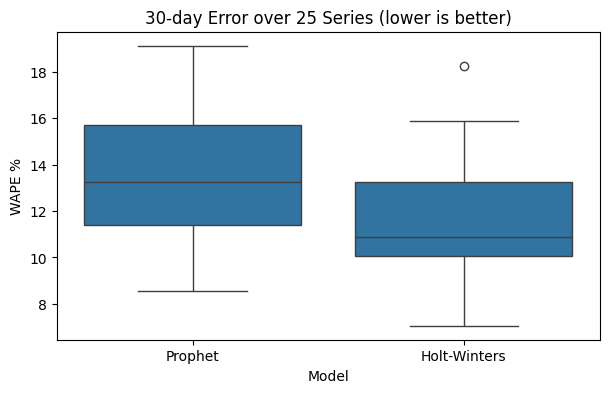

In [84]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=all_results, x="Model", y="WAPE %")
plt.title("30-day Error over 25 Series (lower is better)")
plt.show()

In [85]:
all_results.pivot_table(index="Model", columns="Category", values="WAPE %").round(1)

Category,BEVERAGES,CLEANING,DAIRY,GROCERY I,PRODUCE
Model,,,,,
Holt-Winters,13.4,13.8,10.7,10.8,8.4
Prophet,15.4,13.8,10.1,11.9,17.5


**Conclusion:** the model with the lower average WAPE is the better default. Both models are used in the final forecast below so you can compare their intervals.

## 7. Final forecast – next 7 / 14 / 30 days

Now we train on **all** the data (no hidden days) and predict the 30 days after the last date in the data.

In [86]:
horizon = 30
last_date = subset["ds"].max()
print("Data ends on:", last_date.date())

Data ends on: 2017-08-15


### 7.1 Prophet

In [87]:
final_prophet = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
                        holidays=holidays, interval_width=0.80)
final_prophet.add_regressor("promo")
final_prophet.fit(subset[["ds", "y", "promo"]].dropna())

future = pd.DataFrame({"ds": pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon)})

# We don't know future promotions, so we assume the average of the last 28 days
future["promo"] = subset["promo"].tail(28).mean()

forecast_prophet = final_prophet.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
forecast_prophet.head()

13:14:16 - cmdstanpy - INFO - Chain [1] start processing
13:14:16 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2017-08-16,10162.444509,7298.998734,13070.761465
1,2017-08-17,8622.510433,5634.753683,11425.285991
2,2017-08-18,9943.759495,7088.212865,12680.418296
3,2017-08-19,13938.386478,11318.259598,17008.873173
4,2017-08-20,14941.501426,12028.415305,17714.001298


### 7.2 Holt-Winters

In [88]:
y_all = subset.set_index("ds")["y"].asfreq("D").interpolate()

final_hw = ETSModel(y_all, error="add", trend="add", damped_trend=True,
                    seasonal="add", seasonal_periods=7).fit(disp=False)

hw_future = final_hw.get_prediction(start=len(y_all), end=len(y_all) + horizon - 1).summary_frame(alpha=0.20)

forecast_hw = hw_future.rename(columns={"mean": "yhat", "pi_lower": "yhat_lower", "pi_upper": "yhat_upper"})
forecast_hw["ds"] = future["ds"].values
forecast_hw = forecast_hw[["ds", "yhat", "yhat_lower", "yhat_upper"]]
forecast_hw.head()

,ds,yhat,yhat_lower,yhat_upper
2017-08-16,2017-08-16,8037.270182,4573.317241,11501.223123
2017-08-17,2017-08-17,6305.107809,2815.668142,9794.547475
2017-08-18,2017-08-18,8927.911719,5413.165827,12442.657611
2017-08-19,2017-08-19,12391.298780,8851.423612,15931.173948
2017-08-20,2017-08-20,13199.071098,9634.240158,16763.902038


In [89]:
# Sales cannot be negative
for f in [forecast_prophet, forecast_hw]:
    f["yhat"] = f["yhat"].clip(lower=0)
    f["yhat_lower"] = f["yhat_lower"].clip(lower=0)
    f["yhat_upper"] = f["yhat_upper"].clip(lower=0)

### 7.3 Forecast chart with confidence interval

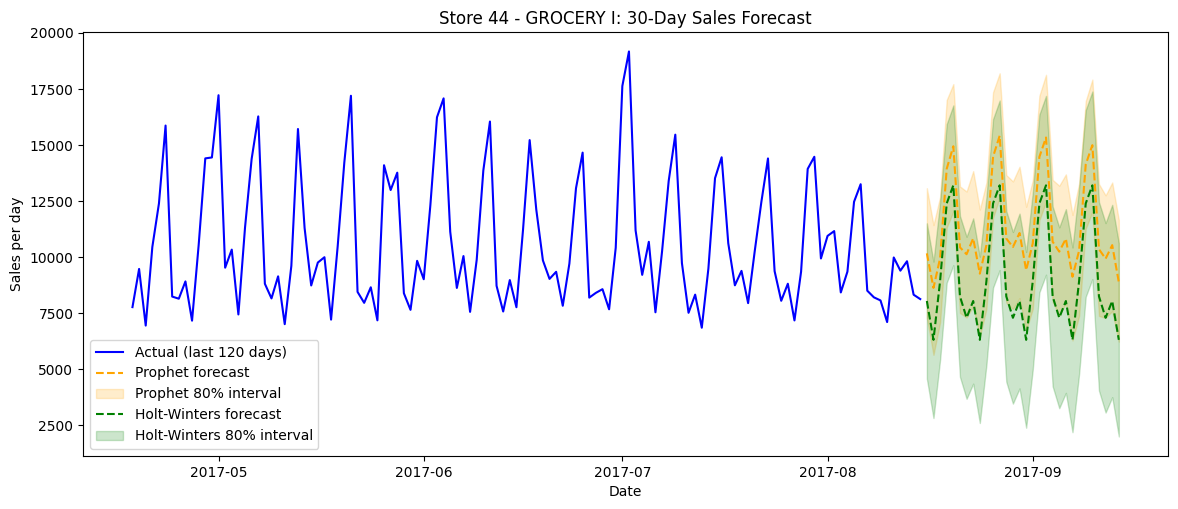

In [90]:
last_120 = subset.tail(120)

plt.figure(figsize=(14, 5.5))
plt.plot(last_120["ds"], last_120["y"], color="blue", label="Actual (last 120 days)")

plt.plot(forecast_prophet["ds"], forecast_prophet["yhat"], "--", color="orange", label="Prophet forecast")
plt.fill_between(forecast_prophet["ds"], forecast_prophet["yhat_lower"], forecast_prophet["yhat_upper"],
                 color="orange", alpha=0.2, label="Prophet 80% interval")

plt.plot(forecast_hw["ds"], forecast_hw["yhat"], "--", color="green", label="Holt-Winters forecast")
plt.fill_between(forecast_hw["ds"], forecast_hw["yhat_lower"], forecast_hw["yhat_upper"],
                 color="green", alpha=0.2, label="Holt-Winters 80% interval")

plt.title("Store 44 - GROCERY I: 30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales per day")
plt.legend()
plt.show()

### 7.4 7, 14 and 30-day demand

In [91]:
summary = []
for days in [7, 14, 30]:
    for name, f in [("Prophet", forecast_prophet), ("Holt-Winters", forecast_hw)]:
        part = f.head(days)
        summary.append([name, days, part["yhat"].sum(), part["yhat_lower"].sum(), part["yhat_upper"].sum()])

summary = pd.DataFrame(summary, columns=["Model", "Days", "Expected demand", "Lower (80%)", "Upper (80%)"])
summary.round(0)

,Model,Days,Expected demand,Lower (80%),Upper (80%)
0,Prophet,7,78163.0,58173.0,97972.0
1,Holt-Winters,7,64393.0,39616.0,89169.0
2,Prophet,14,159937.0,120158.0,199822.0
3,Holt-Winters,14,128783.0,77693.0,179872.0
4,Prophet,30,340770.0,255573.0,426155.0
5,Holt-Winters,30,271900.0,155299.0,388502.0


## 8. Compare forecast demand with stock → alert

The dataset has no stock information, so **we type in the stock ourselves**.

| Status | Rule |
|---|---|
| ✅ **NORMAL** | stock ≥ upper forecast (enough even if demand is high) |
| ⚠️ **AT RISK** | stock ≥ expected forecast but < upper forecast |
| 🚨 **ALERT** | stock < expected forecast (we will run out) |

In [92]:
forecast = forecast_hw         
days = 30                      
current_stock = 280000         

f = forecast.head(days).copy()
expected_demand = f["yhat"].sum()
high_demand = f["yhat_upper"].sum()

print("Current stock          :", round(current_stock))
print("Expected demand        :", round(expected_demand))
print("High-case demand (80%) :", round(high_demand))
print()

if current_stock < expected_demand:
    print("🚨 ALERT: stock is short by", round(expected_demand - current_stock), "units. Restock needed!")
elif current_stock < high_demand:
    print("⚠️ AT RISK: enough for expected demand but not for the high case (short by up to",
          round(high_demand - current_stock), "units).")
else:
    print("✅ NORMAL: stock is enough, buffer of", round(current_stock - high_demand), "units.")

Current stock          : 280000
Expected demand        : 271900
High-case demand (80%) : 388502

⚠️ AT RISK: enough for expected demand but not for the high case (short by up to 108502 units).


### 8.1 Alert for all 25 (store × category) series

Stock is **simulated** here (a random 0.7× to 1.5× of recent 30-day demand) just to show the alert table.

In [93]:
np.random.seed(42)
alert_rows = []

for s in top5_stores:
    for c in top5_categories:

        d = df[(df["store_nbr"] == s) & (df["Category"] == c)]
        d = d[["date", "sales"]].rename(columns={"date": "ds", "sales": "y"})
        d = d.set_index("ds").asfreq("D").reset_index()
        d = d[d["ds"] >= d.loc[d["y"] > 0, "ds"].min()]

        y_d = d.set_index("ds")["y"].asfreq("D").interpolate()
        m = ETSModel(y_d, error="add", trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit(disp=False)
        p = m.get_prediction(start=len(y_d), end=len(y_d) + 29).summary_frame(alpha=0.20)

        expected = p["mean"].clip(lower=0).sum()
        high = p["pi_upper"].clip(lower=0).sum()
        stock_sim = d["y"].tail(28).mean() * 30 * np.random.uniform(0.7, 1.5)

        if stock_sim < expected:
            status = "🚨 ALERT"
        elif stock_sim < high:
            status = "⚠️ AT RISK"
        else:
            status = "✅ NORMAL"

        alert_rows.append([s, c, round(stock_sim), round(expected), round(high), status])

alerts = pd.DataFrame(alert_rows, columns=["Store", "Category", "Stock", "Expected 30-day demand", "High-case demand", "Status"])
alerts

,Store,Category,Stock,Expected 30-day demand,High-case demand,Status
0,44,GROCERY I,298356,270695,387443,⚠️ AT RISK
1,44,BEVERAGES,437015,249016,340501,✅ NORMAL
2,44,PRODUCE,369058,277058,410892,⚠️ AT RISK
3,44,CLEANING,91414,63834,85741,✅ NORMAL
4,44,DAIRY,61921,72254,88636,🚨 ALERT
5,45,GROCERY I,277028,302455,439146,🚨 ALERT
6,45,BEVERAGES,209211,237822,319549,🚨 ALERT
7,45,PRODUCE,273487,191751,282523,⚠️ AT RISK
8,45,CLEANING,95626,66555,96654,⚠️ AT RISK
9,45,DAIRY,84630,64755,79773,✅ NORMAL


In [94]:
alerts["Status"].value_counts()

Status
⚠️ AT RISK    12
🚨 ALERT        9
✅ NORMAL       4
Name: count, dtype: int64

## 9. Save the Holt-Winters models (`model.pkl`) 

In [95]:
import joblib

hw_models = {}

for s in top5_stores:
    for c in top5_categories:

        # build the daily series
        d = df[(df["store_nbr"] == s) & (df["Category"] == c)]
        d = d[["date", "sales"]].rename(columns={"date": "ds", "sales": "y"})
        d = d.set_index("ds").asfreq("D").reset_index()
        d = d[d["ds"] >= d.loc[d["y"] > 0, "ds"].min()]       # start at the first real sale

        # train Holt-Winters on all the data
        y_d = d.set_index("ds")["y"].asfreq("D").interpolate()
        m = ETSModel(y_d, error="add", trend="add", damped_trend=True,
                     seasonal="add", seasonal_periods=7).fit(disp=False)

        hw_models[(int(s), c)] = m
        print("Trained: Store", s, "-", c)

joblib.dump(hw_models, "model.pkl")
print()
print("Saved", len(hw_models), "models to model.pkl")

Trained: Store 44 - GROCERY I
Trained: Store 44 - BEVERAGES
Trained: Store 44 - PRODUCE
Trained: Store 44 - CLEANING
Trained: Store 44 - DAIRY
Trained: Store 45 - GROCERY I
Trained: Store 45 - BEVERAGES
Trained: Store 45 - PRODUCE
Trained: Store 45 - CLEANING
Trained: Store 45 - DAIRY
Trained: Store 47 - GROCERY I
Trained: Store 47 - BEVERAGES
Trained: Store 47 - PRODUCE
Trained: Store 47 - CLEANING
Trained: Store 47 - DAIRY
Trained: Store 3 - GROCERY I
Trained: Store 3 - BEVERAGES
Trained: Store 3 - PRODUCE
Trained: Store 3 - CLEANING
Trained: Store 3 - DAIRY
Trained: Store 49 - GROCERY I
Trained: Store 49 - BEVERAGES
Trained: Store 49 - PRODUCE
Trained: Store 49 - CLEANING
Trained: Store 49 - DAIRY

Saved 25 models to model.pkl


## 10. Conclusion
* Sales follow a strong **weekly pattern**, rise with **promotions** and **holidays**, and also change through the year.
* Two models were compared on the last 30 days held out: **Prophet** and **Holt-Winters**. In section 6.5, **Holt-Winters had the lower average error** (WAPE about 11.4% vs about 13.7% for Prophet) and was better on 14 of 25 series, while Prophet was better on 11 – so neither model wins everywhere.
* Each forecast comes with an **80% confidence interval**, which lets us warn about *risk* (⚠️) and not only about a certain shortage (🚨).
* **Limitations:** recorded sales are not true demand (if an item was out of stock, sales are lower than demand); future promotions are assumed equal to the last 28 days; the data ends on 2017-08-15, so the "next 30 days" are 16 Aug – 14 Sep 2017; stock is entered by the user because the dataset has none.